# ML from DFT data

- [ ] learn on separated FM and NM AGAIN
- [ ] remove high order BOP features before learing
- [X] Recursive Feature elimination after removing high order features
- [ ] make recursion on bond energy
- [X] change OS to 1/10,
- [X] 1/10 OS and scf bop
- [ ] scaled bond integrals
- learn form library features
- compare different regression methods
   - Linear regression
   - add SVM
   - kernel methods
   - Gaussian process.
- compare different test-train splittings
- Learn on increasing domain knowledge

 - input: clean features dataframes from pickles
 - output : plots and Models

In [1]:
from Tools.DatasetTools.Commoms import *
from Tools.DatasetTools.DatasetOperator import Dataset, DatasetTester

In [2]:
from Tools.DatasetTools.Tools import get_str_formatted
from sklearn.model_selection import StratifiedKFold

In [3]:
import matplotlib
from matplotlib.ticker import FormatStrFormatter

# Parameters 

In [4]:
target_case = 'EF_nmhcp'

In [5]:
DS = Dataset('Fe-Mo', target_name=target_case, remove_phases_query='Phase != "bcc" and Phase != "fcc" and Phase !="hcp"')

Possible models are: **Kernel Ridge, MLP and Random Forest**

In [6]:
ModelName = 'Kernel Ridge'

In [7]:
namefile = ModelName.replace(' ', '')

In [8]:
suffix = f"no_hcp_bcc_fcc_{namefile}" #'CV_restart_folds_inloop''CV_restart_folds_inloop

In [9]:
(DS.BS.Phase == 'hcp').sum()

0

# Targets

In [10]:
plt.rc('text', usetex=False)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


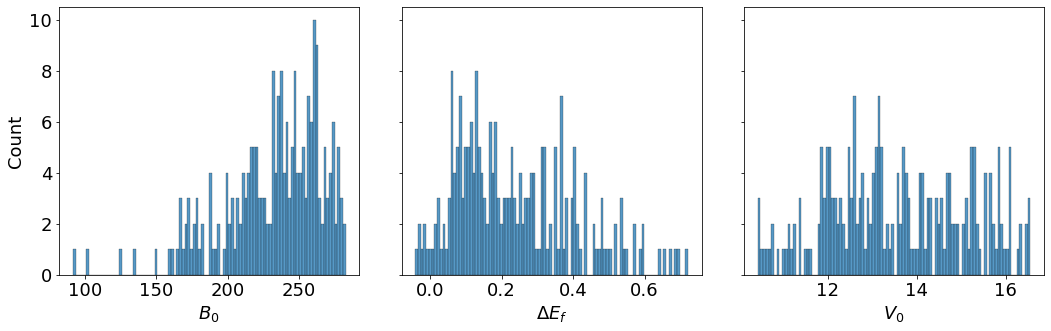

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0], bins=100)
sns.histplot( DS.BS[target_case], ax= ax[1], bins=100)
sns.histplot( DS.BS['V0'], ax= ax[2], bins = 100)
ax[0].set_xlabel('$B_0$')
ax[1].set_xlabel(r'$\Delta E_f$')
ax[2].set_xlabel('$V_0$')
fig.tight_layout()
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_target_distributions_{target_case}.eps')

In [12]:
DS.BS.B0.idxmax()

'Fe_pv8Mo_sv4.C14-BAA.NM'

In [13]:
DS.BS.query('B0 < 150')

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_nmhcp,EF_nmfcc,EF_fmbcc,Phase
Fe_pv12.C14.FM,bulk C14.FM,12.119019 A,-8.105991,102.152576 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,12,0,12,1.000000,0.000000,0.149303,0.149303,0.149303,C14
Fe_pv8.A15.FM,bulk A15.FM,11.558019 A,-8.169759,91.497861 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,8,0,8,1.000000,0.000000,0.085535,0.085535,0.085535,A15
Fe_pv25Mo_sv4.chi-ABAA.FM,bulk chi-ABAA.FM,11.874474 A,-8.560894,134.837320 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,25,4,29,0.862069,0.137931,0.063911,0.063911,0.063911,chi
Fe_pv24Mo_sv5.chi-BBAA.FM,bulk chi-BBAA.FM,11.926180 A,-8.658669,124.301732 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,24,5,29,0.827586,0.172414,0.058514,0.058514,0.058514,chi


# Machine Learning 

In [14]:
from Tools.DatasetTools.MLConveniences import *

In [15]:
resultslocation = DS.resultslocation

## Feature sets

In [16]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

## BOP features with and without CP averages

In [17]:
# Features.update({name+' no Zeros': clean_zeros(name, features) for name, features in Features.items() if notyetclean(name)} )

## test - train splits

In [18]:
samplesplit = DS.get_samplesplit()

<AxesSubplot:xlabel='Phase', ylabel='Count'>

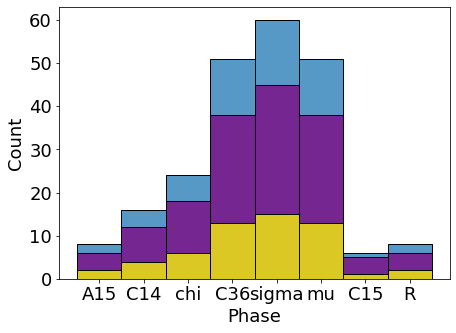

In [19]:
ax = sns.histplot(DS.StructureNames)
sns.histplot(DS.StructureNames.loc[samplesplit['train']], ax = ax, color = 'purple')
sns.histplot(DS.StructureNames.loc[samplesplit['test']], ax = ax, color = 'yellow')

# Models: adjust params

In [20]:
import warnings
warnings.simplefilter('ignore')

In [21]:
Models = {
    'Kernel Ridge': Pipeline([('scaler', StandardScaler()), ('regressor', KernelRidge())]),
    'MLP': Pipeline([('scaler', StandardScaler()), ('regressor', MLPRegressor())]),
    'Random Forest': Pipeline([('regressor', RandomForestRegressor())]),
    'Gaussian Process': Pipeline([('regressor', GaussianProcessRegressor())])
}

In [22]:
from importlib.machinery import SourceFileLoader
MO = SourceFileLoader('MO', 'Tools/DatasetTools/ModelSelection.py').load_module().ModelOptions(DS.dataset)

In [23]:
MO.load_model_options(ModelName)

In [24]:
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, RationalQuadratic, ConstantKernel, ExpSineSquared, DotProduct, Product

##  Features

In [25]:
DS.BS.index[DS.BS.index.str.contains('bcc')]

Index([], dtype='object')

In [26]:
Features['Projections OS BOP'].index[Features['Projections OS BOP'].index.str.contains('bcc')]

Index([], dtype='object')

In [27]:
Features['0.7 Projections OS BOP'].index[Features['0.7 Projections OS BOP'].index.str.contains('bcc')]

Index([], dtype='object')

In [28]:
DS.target.index.difference(Features['Projections OS BOP'].index)

Index([], dtype='object')

In [29]:
for name, thefeatures in Features.items():
    print(name, thefeatures.shape)

atomic (224, 135)
dataset (224, 32)
SOAP_canonicalFe (224, 100)
SOAP_canonicalW (224, 100)
SOAP_specific (224, 198)
Pyscal (224, 15)
ACE (224, 1797)
Canonical ACE (224, 411)
Canonical BOP (224, 393)
Projections BOP (224, 393)
Projections OS BOP (224, 393)
0.6 Projections OS BOP (224, 393)
0.7 Projections OS BOP (224, 393)
0.8 Projections OS BOP (224, 393)
dataset + Canonical BOP (224, 422)
dataset + Projections BOP (224, 422)
dataset + Projections OS BOP (224, 422)
dataset + 0.6 Projections OS BOP (224, 422)
dataset + 0.7 Projections OS BOP (224, 422)
dataset + 0.8 Projections OS BOP (224, 422)
atomic no CNAV (224, 135)
dataset no CNAV (224, 17)
SOAP_canonicalFe no CNAV (224, 16)
SOAP_canonicalW no CNAV (224, 16)
SOAP_specific no CNAV (224, 75)
Pyscal no CNAV (224, 5)
ACE no CNAV (224, 302)
Canonical ACE no CNAV (224, 71)
Canonical BOP no CNAV (224, 68)
Projections BOP no CNAV (224, 68)
Projections OS BOP no CNAV (224, 68)
0.6 Projections OS BOP no CNAV (224, 68)
0.7 Projections OS BOP

In [30]:
Features['0.7 Projections OS BOP'].index[Features['0.7 Projections OS BOP'].index.str.contains('bcc')]

Index([], dtype='object')

# Feature Selection

In [31]:
suffix

'no_hcp_bcc_fcc_KernelRidge'

In [32]:
feature_concat_resul_loc = os.path.join(DS.dataset, 'results', f'concatenation_results_{target_case}_{suffix}.pkl')  
if os.path.exists(feature_concat_resul_loc):
    with open(feature_concat_resul_loc, 'rb') as pkl:
        savedFCresults = pickle.load(pkl)
else:
    savedFCresults = {}

In [33]:
FCresults = {}

In [34]:
for combi, selectionloop in savedFCresults.items():
    print (combi)
    FCresults[combi] = []
    for thisloop in selectionloop:
        badnews =  'random' in thisloop.index
        if badnews:
            print(badnews, thisloop.index.get_loc('random'),'/', len (thisloop))
            thisloop=thisloop.loc[:'random'].iloc[:-1]
        else:
            print (badnews)
            FCresults[combi].append(thisloop)
        if len(thisloop) < 1:
            continue

('Kernel Ridge', '0.6 Projections OS BOP')
False
('Kernel Ridge', '0.7 Projections OS BOP')
False
False
False
False
True 16 / 120
True 22 / 50
('Kernel Ridge', '0.7 Projections OS BOP no CNAV')
True 50 / 51
True 43 / 44
True 44 / 46
False
False
True 44 / 45
('Kernel Ridge', 'ACE no CNAV')
False
False
False
False
False
False
('Kernel Ridge', 'Canonical BOP')
True 171 / 172
True 171 / 172
True 165 / 172
False
False
False
('Kernel Ridge', 'Canonical BOP no CNAV')
True 46 / 47
True 45 / 46
True 0 / 42
False
True 40 / 41
True 41 / 42
('Kernel Ridge', 'Projections OS BOP')
True 75 / 119
False
False
False
False
False
('Kernel Ridge', 'SOAP_canonicalFe')
True 15 / 45
True 6 / 46
True 6 / 46
True 4 / 41
True 41 / 42
True 41 / 42
('Kernel Ridge', 'SOAP_specific')
True 106 / 124
False
False
False
True 13 / 67
True 11 / 66
('Kernel Ridge', 'SOAP_specific no CNAV')
True 39 / 40
True 6 / 40
True 6 / 40
True 37 / 39
True 14 / 34
True 10 / 29
('Kernel Ridge', 'atomic')
True 5 / 10
True 0 / 6
True 0 / 

In [35]:
for combi, selectionloop in FCresults.items():
    print (combi)
    for thisloop in selectionloop:
        badnews =  'random' in thisloop.index
        if badnews:
            print(badnews, thisloop.index.get_loc('random'),'/', len (thisloop))
        else:
            print (badnews)

('Kernel Ridge', '0.6 Projections OS BOP')
False
('Kernel Ridge', '0.7 Projections OS BOP')
False
False
False
False
('Kernel Ridge', '0.7 Projections OS BOP no CNAV')
False
False
('Kernel Ridge', 'ACE no CNAV')
False
False
False
False
False
False
('Kernel Ridge', 'Canonical BOP')
False
False
False
('Kernel Ridge', 'Canonical BOP no CNAV')
False
('Kernel Ridge', 'Projections OS BOP')
False
False
False
False
False
('Kernel Ridge', 'SOAP_canonicalFe')
('Kernel Ridge', 'SOAP_specific')
False
False
False
('Kernel Ridge', 'SOAP_specific no CNAV')
('Kernel Ridge', 'atomic')
('Kernel Ridge', 'atomic no CNAV')
('Kernel Ridge', 'dataset')
('Kernel Ridge', 'dataset no CNAV')
False
False
('Kernel Ridge', 'ACE')
False
False
False
False
False
False
False
False
False
False
False
False
False
('Kernel Ridge', 'Canonical ACE')
False
False
False
False
('Kernel Ridge', 'Canonical ACE no CNAV')
False
False
False
False


In [36]:
nowantoplot = ['0.6 Projections OS BOP','0.8 Projections OS BOP', 'Projections OS BOP', 'atomic no CNAV', 'dataset no CNAV', 'SOAP_canonicalFe']

In [37]:
iwanttoplot = [combi[1] for combi in FCresults.keys() if combi[0] == ModelName and combi[1] not in nowantoplot and len(FCresults[combi])>0]# and 'no CNAV' not in combi[1] and combi[1] != 'ACE']

In [38]:
for featurename in iwanttoplot:
    print(featurename, len(FCresults[(ModelName, featurename)]))

0.7 Projections OS BOP 4
0.7 Projections OS BOP no CNAV 2
ACE no CNAV 6
Canonical BOP 3
Canonical BOP no CNAV 1
SOAP_specific 3
ACE 13
Canonical ACE 4
Canonical ACE no CNAV 4


In [39]:
iwanttoplot

['0.7 Projections OS BOP',
 '0.7 Projections OS BOP no CNAV',
 'ACE no CNAV',
 'Canonical BOP',
 'Canonical BOP no CNAV',
 'SOAP_specific',
 'ACE',
 'Canonical ACE',
 'Canonical ACE no CNAV']

In [40]:
pallete = sns.color_palette(n_colors=len(iwanttoplot))

In [41]:
colors = {name: c for name, c in zip(iwanttoplot, pallete)}

In [42]:
# iwanttoplot = ['atomic', 'dataset', 'Canonical BOP', 'dataset + Canonical BOP', 'Projections BOP', 'dataset + Projections BOP', 'Projections sOS BOP', 'dataset + Projections sOS BOP' ]
#iwanttoplot = ['ACE','SOAP_specific',  'Canonical BOP', 
#iwanttoplot = ['Projections OS BOP']#, 'Projections sOS BOP']#, 'SOAP_canonicalW',

In [43]:
folder = StratifiedKFold(shuffle=True)
folds_generator = folder.split(DS.samplesplit['train'], DS.StructureNames[DS.samplesplit['train']])
train_folds = list(folds_generator)
TestCV = GridSearchCV(Models[ModelName], MO.modeloptions[ModelName], cv = train_folds, return_train_score=True)

In [44]:
FittedGS = {}

In [45]:
MO.modeloptions

{'Kernel Ridge': {'regressor__alpha': [1.0, 0.1, 0.01],
  'regressor__kernel': ['polynomial'],
  'regressor__degree': [2, 3, 4, 5],
  'regressor__coef0': [0, 1, 2, 3, 4, 5]}}

# DS.Features.keys(): #['Canonical BOP']:
for featurename in iwanttoplot: #FittedModels.items():
    print(featurename)
    if 'random' not in Features[featurename]:
        Features[featurename]['random'] = np.random.rand(DS.target.shape[0])
    corrs = pd.concat([Features[featurename], DS.target], axis=1).corr().abs()[target_case]
    
    reasonable_features = corrs[corrs > corrs['random']].index.difference([target_case])
    combi = (ModelName, featurename)
#   model = copy.deepcopy(fmodel.best_estimator_)
    if len(FCresults[combi]) >= 1 :
        continue
    FittedGS[combi] = copy.deepcopy(TestCV)
    FC = FeatureConcatenate(DS, FittedGS[combi],  MO.modeloptions[ModelName]) #fmodel.best_params_,)model_params_grid =
    FCresults[combi].append (FC.get_best_features_list(combi[1], num_features = 2, max_workers=3, search_only = reasonable_features))#DS.Features[combi[1]].shape[1]
    with open(feature_concat_resul_loc, 'wb') as pkl:
        pickle.dump(FCresults, pkl)

In [46]:
#with open(feature_concat_resul_loc, 'wb') as pkl:
#    pickle.dump(FCresults, pkl)

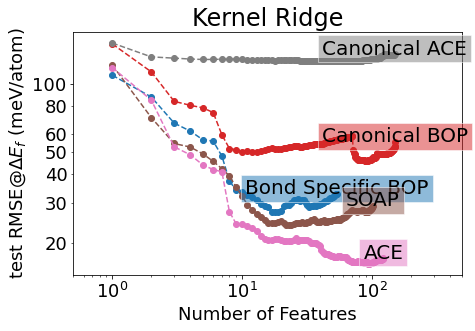

In [47]:
from matplotlib.ticker import FormatStrFormatter
fig, axes = plt.subplots()
for combi, result in FCresults.items():
    if len(result) < 1:
        continue
    if combi[0] != ModelName:
        continue
    if combi[1] not in iwanttoplot:
        continue
    if 'no CNAV' in combi[1]:
        continue
#    if ' OS ' in combi[1]:
#        continue
    nfeats = result[-1].shape[0]
    x=np.linspace(1,nfeats, nfeats)
    legend = combi[1].replace('dataset', 'polyhedra')
    legend = legend.replace('atomic', 'Matminer')\
        .replace('_specific','').replace('0.7 ','')\
        .replace('polyhedra','atomic + OneHot')\
        .replace('Projections OS BOP', 'Bond Specific BOP')
    y = result[-1]['test']*1000
    axes.plot(x, y ,'--o',c=colors[combi[1]], label=legend)
    text = axes.text(x[-1], y[-1], legend, horizontalalignment='center')#, backgroundcolor='white', alpha=0.5)
    text.set_bbox(dict(facecolor=colors[combi[1]], alpha=0.5,edgecolor='white'))
axes.set_xscale('log')
axes.set_ylabel(r'test RMSE@$\Delta E_f$ (meV/atom)')
axes.set_xlabel('Number of Features')
axes.tick_params(axis='y', which='minor')
axes.set_yscale('log', subs = [0.2, 0.3, 0.4,0.5, 0.6, 0.8])
axes.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
axes.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
#plt.legend(bbox_to_anchor=(0.6,0.5))
axes.set_xlim([0.5, 0.5e3])
axes.set_title(ModelName)
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves_{target_case}_{nameforfile}.pdf')

In [48]:
'Mag' in FCresults[(ModelName, '0.7 Projections OS BOP no CNAV' )][-1].index

True

In [49]:
combi = (ModelName, '0.7 Projections OS BOP')
selected_pos = FCresults[combi][-1].index[0]
y_pos = FCresults[combi][-1]['test']*1000
x = np.linspace(1, len(y_pos), len(y_pos))
axes.annotate(get_str_formatted(selected_pos), (x[0], y_pos[0]-5), xytext=(x[0]-0.1, y_pos[0]-40), arrowprops={'facecolor':'black'})
selected_next = FCresults[combi][-1].index[1]
axes.annotate(get_str_formatted(selected_next), (x[1], y_pos[1]), xytext=(x[1]*2, y_pos[1]+20), arrowprops={'facecolor':'black'})
ymag = y_pos[y_pos.index=='Mag']['Mag']
xmag = x[y_pos.index=='Mag']
axes.annotate('Mag', (xmag-0.1, ymag-1), xytext=(xmag/5, ymag-10), arrowprops={'facecolor':'black'})
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves_annotated_{target_case}_CV.pdf')

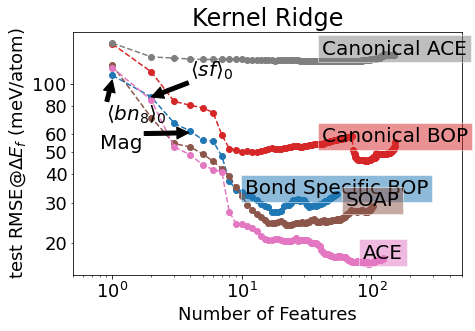

In [50]:
fig

## Feature Selection

In [51]:
iwanttoplot_all = [feature for feature in iwanttoplot if 'no CNAV' not in feature and 'dataset' not in feature and 'atomic' in feature]

In [52]:
iwanttoplot_all = {'dataset': 'atomic + OneHot', '0.7 Projections OS BOP': 'BOP', 'SOAP_specific': 'SOAP', 'ACE':'ACE'}

In [53]:
from matplotlib import __version__

In [54]:
def plot_panel_learning_curves(feature_list: dict):# -> list[matplotlib.axes._subplots.Axes]: 
    nplots = len(feature_list)
    width = plt.rcParams['figure.figsize'][0]*(3/5)*nplots
    height = plt.rcParams['figure.figsize'][1]
    fig, axes = plt.subplots(1,nplots, figsize=(width, height), sharey = True)# figsize=(width, 5*width/13),
    for (featurename, featurelabel), ax in zip(feature_list.items(), axes):
        combi = (ModelName, featurename)
        ax.set_title(featurelabel)
        results = FCresults[combi]
        for j, result in enumerate(results):
            x = np.linspace(1, result.shape[0], result.shape[0])
            sns.scatterplot(x=x, y=result['test']*1000, ax=ax)
        ax.set_yscale('log', subs=[2, 4, 6, 8, 10])
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
#    ax.set_ylim([19, 110])
    ax.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
    ax.tick_params(axis='y', which = 'minor')
    axes[0].set_xticks([1, 5, 10])
    axes[0].set_ylabel(r'test RMSE @$\Delta E_f$ (meV/at)')
    fig.supxlabel('Number of features')
    return fig, axes
#    axes[i-1].set_xticklabels('')
#axes[0].yaxis.set_major_formatter(FormatStrFormatter("%.0e"))

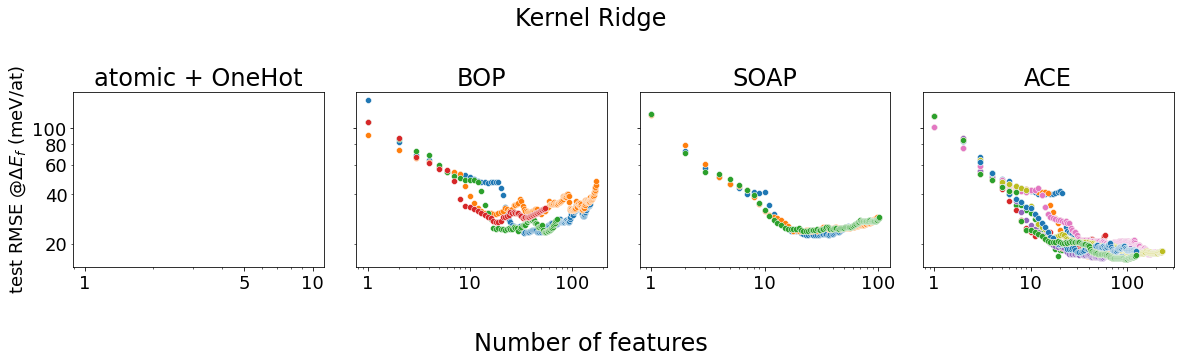

In [55]:
fig, axes = plot_panel_learning_curves(iwanttoplot_all)
nameinfile = ModelName.replace(' ','')
fig.suptitle('Kernel Ridge')
fig.tight_layout()
fig.savefig(os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_{nameinfile}_learning_curves_tovote.pdf'))

## Feature transformers

In [56]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import RegressorMixin

In [57]:
def get_optimal_feature_score(FeatureScoreData:pd.core.frame.DataFrame):
    thisatmin = FeatureScoreData['test'].argmin()
    return FeatureScoreData[:thisatmin]

In [58]:
def get_optimal_features(FeatureScoreData:pd.core.frame.DataFrame):
    thisatmin = FeatureScoreData['test'].argmin()
    return FeatureScoreData.index[:thisatmin]

In [59]:
def filter_features (Features_DF: pd.core.frame.DataFrame, learning_curve = pd.core.frame.DataFrame):
    if 'params' not in learning_curve.columns:
        raise ValueError('the learning curve provided is not an evaluation of best features')
    columns = get_optimal_features(learning_curve)
    return Features_DF[columns]

def get_optimal_feature_names(Features_DF: pd.core.frame.DataFrame, learning_curve = pd.core.frame.DataFrame):
    columns = get_optimimal_features(learning_curve)
    return columns

In [60]:
class AverageEnsambleRegressor():
    def __init__(self, named_estimators = list[tuple[str, RegressorMixin]]):
        self.named_estimators_ : list[tuple[str, RegressorMixin]] = named_estimators

    def fit(self, _X : pd.core.frame.DataFrame , _Y : pd.core.series.Series) -> pd.core.series.Series:

        for name, estimator in self.named_estimators_:
            estimator.fit(_X, _Y)

    def predict(self, _X : pd.core.frame.DataFrame) -> pd.core.series.Series:

        self.predictions_ = pd.concat(
            [pd.Series(estimator.predict(_X), name=name, index=_X.index) for name, estimator in self.named_estimators_],
            axis=1
        )

        return self.predictions_.mean(axis=1)

    def get_prediction_std(self):
        if not hasattr(self, 'predictions_'):
            pdb.set_trace()
            raise NameError('you must fit the models first')

        err = self.predictions_.std(axis=1)
        return err

In [61]:
combi = (ModelName, '0.7 Projections OS BOP')

In [62]:
RegresorsBag = {}

In [63]:
from sklearn.ensemble import VotingRegressor

In [64]:
VotedScores = {}
AveragedScores = {}

In [65]:
voting_regressor = {}
average_regressor = {}
indexedregressorbag = {}

## Voting Regressor based on regressor bag

In [66]:
for combi, LearningCurveList in FCresults.items():
    RegresorsBag[combi] = []
    if combi[1] not in Features.keys():
        continue
    if combi[0] != ModelName:
        continue
    if len(LearningCurveList) < 1:
        continue
    for LearningCurve in LearningCurveList:
        transformer = FunctionTransformer(
            filter_features, kw_args = {'learning_curve' : LearningCurve}, 
        )
        RegresorsBag[combi].append(copy.deepcopy(Models[ModelName])) 
        RegresorsBag[combi][-1].steps.insert(0, ['feature_selection', transformer])
        thiscurve = LearningCurve
        RegresorsBag[combi][-1].set_params(**thiscurve.params.iloc[-1])
    
    indexedregressorbag[combi] = [(str(i), thisregressor) for i, thisregressor in enumerate(RegresorsBag[combi])]
    if len(indexedregressorbag) < 1:
        continue

    voting_regressor[combi] = VotingRegressor(indexedregressorbag[combi])
    voting_regressor[combi].fit(Features[combi[1]].loc[DS.samplesplit['train']], DS.target.loc[DS.samplesplit['train']])


    VotedScores[combi] = score_fitted_model(
        voting_regressor[combi], 
        Features[combi[1]].loc[DS.samplesplit['train']],
        Features[combi[1]].loc[DS.samplesplit['test']],
        DS.target[DS.samplesplit['train']],
        DS.target[DS.samplesplit['test']])

In [67]:
for combi, votingregressor in voting_regressor.items():
    for index, pipeline in votingregressor.estimators:
        learning_curve = pipeline.named_steps['feature_selection'].kw_args['learning_curve']
        print(combi, len(learning_curve))


('Kernel Ridge', '0.6 Projections OS BOP') 164
('Kernel Ridge', '0.7 Projections OS BOP') 149
('Kernel Ridge', '0.7 Projections OS BOP') 172
('Kernel Ridge', '0.7 Projections OS BOP') 71
('Kernel Ridge', '0.7 Projections OS BOP') 54
('Kernel Ridge', '0.7 Projections OS BOP no CNAV') 26
('Kernel Ridge', '0.7 Projections OS BOP no CNAV') 43
('Kernel Ridge', 'ACE no CNAV') 191
('Kernel Ridge', 'ACE no CNAV') 76
('Kernel Ridge', 'ACE no CNAV') 31
('Kernel Ridge', 'ACE no CNAV') 65
('Kernel Ridge', 'ACE no CNAV') 93
('Kernel Ridge', 'ACE no CNAV') 46
('Kernel Ridge', 'Canonical BOP') 90
('Kernel Ridge', 'Canonical BOP') 144
('Kernel Ridge', 'Canonical BOP') 152
('Kernel Ridge', 'Canonical BOP no CNAV') 37
('Kernel Ridge', 'Projections OS BOP') 131
('Kernel Ridge', 'Projections OS BOP') 72
('Kernel Ridge', 'Projections OS BOP') 56
('Kernel Ridge', 'Projections OS BOP') 94
('Kernel Ridge', 'Projections OS BOP') 52
('Kernel Ridge', 'SOAP_specific') 78
('Kernel Ridge', 'SOAP_specific') 97
('Ker

# SAVE THE REGRESSOR!

In [68]:
VotingRegressor

sklearn.ensemble._voting.VotingRegressor

In [69]:
regresorbag_file =os.path.join(DS.dataset, 'results', f'regressors_bag_{nameforfile}.pkl')

In [70]:
indexedbags_file = os.path.join(DS.dataset, 'results', f'indexed_bag_{nameforfile}.pkl')

In [71]:
regressor_file = os.path.join(DS.dataset, 'results', f'voting_regressor_{nameforfile}.pkl')

In [72]:
import joblib

In [73]:
joblib.dump(RegresorsBag, regresorbag_file)
joblib.dump(indexedregressorbag, indexedbags_file)
joblib.dump(voting_regressor, regressor_file)

['Fe-Mo/results/voting_regressor_KernelRidge.pkl']

In [74]:
voting_regressor = joblib.load(regressor_file)

In [75]:
os.path.exists(regressor_file)

True

In [76]:
err_test = {}
for (featurename, featuretag), ax in zip(iwanttoplot_all.items(), axes):
    ax.grid('on')
    if featurename not in Features.keys():
        continue
    combi = (ModelName, featurename)
    if combi not in voting_regressor.keys():
        continue
    bagging_regressor = voting_regressor[combi]
    err_test[featurename] = (bagging_regressor.predict(Features[featurename].loc[DS.samplesplit['test']]) - DS.target[DS.samplesplit['test']]).abs()

In [77]:
min_err_test =min( [  err.min() for err in err_test.values() ] )

In [78]:
min_err_test

3.551756299320641e-05

In [79]:
max_err_test =min( [  err.max() for err in err_test.values() ] )

In [80]:
max_err_test

0.06041457236400444

In [81]:
logbins = np.logspace(np.log10(min_err_test*1000), np.log10(max_err_test*1000), 10)

In [82]:
VotedScores

{('Kernel Ridge', '0.6 Projections OS BOP'): {'test': 0.03490412011220785,
  'train': 0.023561917563342975},
 ('Kernel Ridge', '0.7 Projections OS BOP'): {'test': 0.019764944553022003,
  'train': 0.021000711376559508},
 ('Kernel Ridge',
  '0.7 Projections OS BOP no CNAV'): {'test': 0.03471684687361124, 'train': 0.018284815174060897},
 ('Kernel Ridge', 'ACE no CNAV'): {'test': 0.017910527198701554,
  'train': 0.01190054148126441},
 ('Kernel Ridge', 'Canonical BOP'): {'test': 0.04218826489031219,
  'train': 0.03233113901798829},
 ('Kernel Ridge', 'Canonical BOP no CNAV'): {'test': 0.07868061899022369,
  'train': 0.04784152602034537},
 ('Kernel Ridge', 'Projections OS BOP'): {'test': 0.018463137236314865,
  'train': 0.009053022799029191},
 ('Kernel Ridge', 'SOAP_specific'): {'test': 0.022868831441462966,
  'train': 0.011648109024302307},
 ('Kernel Ridge', 'dataset no CNAV'): {'test': 0.08852924891443735,
  'train': 0.07648495491142422},
 ('Kernel Ridge', 'ACE'): {'test': 0.014663841054011

nplots = len(iwanttoplot_all)
width = nplots*plt.rcParams['figure.figsize'][0]*(3/5)
height = plt.rcParams['figure.figsize'][1]
fig, axes = plt.subplots(1, nplots, sharex = True, sharey = True, figsize=(width, height))

for (featurename, featuretag), ax in zip(iwanttoplot_all.items(), axes):
    ax.grid('on')
    if featurename not in Features.keys():
        continue
    combi = (ModelName, featurename)
    bagging_regressor = voting_regressor[combi]
#    err_test = (bagging_regressor.predict(Features[featurename].loc[DS.samplesplit['test']]) - DS.target[DS.samplesplit['test']]).abs()
#    rmse_test = np.sqrt((err_test[featurename]**2).sum()/len(err_test))
    rmse_test = VotedScores.loc[(ModelName, featurename)]['test']
    ax = sns.histplot(
        data=err_test[featurename],
        y=err_test[featurename].values*1000, 
        ax=ax,  #binrange=[0, 100],
        bins=logbins, #50, 
        color = ['blue'],
        edgecolor = 'black',
        linewidth = 2
    )#, hue =DS.StructureNames[DS.samplesplit['test']])#.plot.hist( ax=ax)
    ax.set_xlabel('')
    ax.set_title(f'{featuretag} {len(err_test[featurename])}' )
    ax.axhline(np.log10(err_test[featurename].std()*1000), color='mediumseagreen', label = 'std', linewidth = 5)
    ax.axhline(np.log10(rmse_test*1000), color='crimson', label = 'RMSE', linewidth = 5)
    ax.axhline(np.log10(err_test[featurename].mean()*1000), label='MAE', color='chocolate', linewidth=5)
#    ax.get_legend().remove()
axes[0].set_ylabel(r'$|\Delta E_f ^{predict} - \Delta E_f ^{target}|_{test}$ (meV/at)')
axes[0].set_yscale('log')
fig.supxlabel('Counts', x=0.5, y=0.05)
fig.suptitle(ModelName)
fig.tight_layout()
leg_handles, leg_labels = axes[0].get_legend_handles_labels()
fig.legend(leg_handles, leg_labels, ncol=3)
fig_file_name = os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_{nameforfile}_ErrorDistributions_{target_case}.pdf')
plt.savefig(fig_file_name)

In [83]:
err_test['ACE'].mean()

0.009933299004206916

VotedScores.loc[(ModelName, 'ACE')]

In [84]:
VotedScores = pd.DataFrame.from_dict(VotedScores, orient = 'index')

In [85]:
VotedScores = VotedScores.sort_values('test', ascending = False).sort_index(level=1)

In [86]:
VotedScores

test     train
Kernel Ridge 0.6 Projections OS BOP          0.034904  0.023562
             0.7 Projections OS BOP          0.019765  0.021001
             0.7 Projections OS BOP no CNAV  0.034717  0.018285
             ACE                             0.014664  0.011965
             ACE no CNAV                     0.017911  0.011901
             Canonical ACE                   0.134706  0.134493
             Canonical ACE no CNAV           0.131099  0.133610
             Canonical BOP                   0.042188  0.032331
             Canonical BOP no CNAV           0.078681  0.047842
             Projections OS BOP              0.018463  0.009053
             SOAP_specific                   0.022869  0.011648
             dataset no CNAV                 0.088529  0.076485

In [87]:
VotedScores.to_pickle(os.path.join(DS.dataset,'results', f'{DS.dataset}_{ModelName}_OptimalScores_{target_case}.pkl'))

In [88]:
PlotVotedScores = 1000*VotedScores[~VotedScores.index.levels[1].str.contains('^0.6|^0.8')]

In [89]:
unstack = PlotVotedScores.unstack(level=0).sort_index()

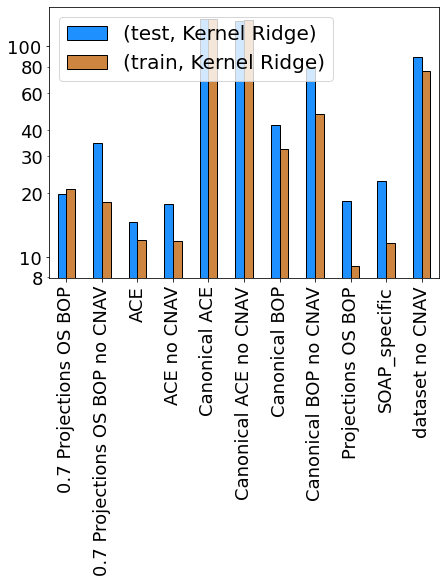

In [90]:
ax = PlotVotedScores.unstack(level=0).sort_index().plot.bar(
    color = ['dodgerblue', 'peru'], edgecolor = 'black'
)#.sort_values(by=('test', ModelName), ascending=False)*1000).plot.bar()
ax.set_yscale('log', subs=[2,3, 4, 6, 8, 10])
ax.get_legend().set_title('')
ax.tick_params(axis='y', which = 'minor')                                                                                                     
ax.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))

# Prediction line 

In [91]:
from sklearn.ensemble._voting import VotingRegressor as type_voting_regressor

In [92]:
def get_bag_of_predictions(bag_of_regressors : type_voting_regressor, features_df  : pd.core.frame.DataFrame):
    bag_of_predictions = {}
    for name, regressor_in_bag in enumerate(bag_of_regressors):
        bag_of_predictions[name] = regressor_in_bag.predict(features_df)
        bag_of_predictions [name] = pd.Series(bag_of_predictions[name],name=name,  index=features_df.index)
    return pd.concat(bag_of_predictions, axis=1)
    

In [93]:
predictions={}
stds={}
Prediction = {} 

In [94]:
for name, regressor in voting_regressor.items():
    Prediction[name] = regressor.predict(Features[name[1]])
    Prediction[name] = pd.DataFrame(Prediction[name], index = Features[name[1]].index, columns=[DS.target_name])
    predictions[name] = get_bag_of_predictions(regressor.estimators_, Features[name[1]])
    stds[name] = predictions[name].std(axis=1)

# Predicted BS 

In [95]:
predictedBS = copy.copy(DS.BS.loc[DS.target.index])

In [96]:
for combi, prediction in Prediction.items():
    predictedBS[f'EF_nmhcp_{combi[1]}'] = prediction

In [97]:
predictedBS.filter(regex='EF_nmhcp_*')

,EF_nmhcp,EF_nmhcp_0.6 Projections OS BOP,EF_nmhcp_0.7 Projections OS BOP,EF_nmhcp_0.7 Projections OS BOP no CNAV,EF_nmhcp_ACE no CNAV,EF_nmhcp_Canonical BOP,EF_nmhcp_Canonical BOP no CNAV,EF_nmhcp_Projections OS BOP,EF_nmhcp_SOAP_specific,EF_nmhcp_dataset no CNAV,EF_nmhcp_ACE,EF_nmhcp_Canonical ACE,EF_nmhcp_Canonical ACE no CNAV
Fe_pv8.A15.FM,0.085535,0.087062,0.082811,0.088404,0.082552,0.087597,0.083298,0.086257,0.096010,0.148717,0.092700,0.126736,0.090477
Fe_pv12.C14.FM,0.149303,0.161815,0.149219,0.139179,0.152186,0.139506,0.158510,0.145131,0.149584,0.232822,0.153544,0.246476,0.131747
Fe_pv24Mo_sv5.chi-BBAA.FM,0.058514,0.057623,0.056099,0.045671,0.049595,0.051375,0.044795,0.056321,0.052675,0.073486,0.053246,0.173207,0.095638
Fe_pv25Mo_sv4.chi-ABAA.FM,0.063911,0.063193,0.061875,0.054682,0.050874,0.069363,0.076733,0.062251,0.052314,0.069823,0.060333,0.168125,0.088694
Fe_pv24.C36.FM,0.145580,0.144615,0.162507,0.155698,0.185251,0.138316,0.132571,0.154395,0.159692,0.246330,0.165262,0.225025,0.147346
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv24Mo_sv5.chi-BBAA.NM,0.052194,0.056332,0.057367,0.059404,0.060351,0.042847,0.043218,0.052603,0.054442,0.073486,0.051639,0.173207,0.156596
Fe_pv4Mo_sv2.C15-A2B.NM,0.009861,0.095036,0.082796,0.001344,0.010943,0.022655,0.058346,0.042696,0.010698,0.024275,0.035187,0.135116,0.290955
Fe_pv25Mo_sv4.chi-ABAA.NM,0.057857,0.058344,0.062687,0.064674,0.077867,0.067555,0.085150,0.060012,0.075087,0.069823,0.067076,0.168125,0.153263
Fe_pv16Mo_sv8.C36-BBAAA.NM,-0.016932,-0.021674,0.008906,0.000708,-0.007653,-0.030888,-0.071091,-0.010066,-0.026662,0.166155,-0.015306,0.270114,0.284030


## save the prediction

In [98]:
predictedBS.to_pickle(os.path.join(DS.dataset, 'results', f'{DS.dataset}_{ModelName}_PredictedBS.pkl'))

In [99]:
#iwanttoplot = {'atomic':'Matminer',
iwanttoplot = {'atomic': 'atomic', '0.7 Projections OS BOP':'Bond specific BOP'}
#iwanttoplot = {'dataset': 'dataset', 'Projections OS BOP':'Projections OS BOP'}

atomic atomic
('Kernel Ridge', 'atomic') has not been processed yet
0.7 Projections OS BOP Bond specific BOP


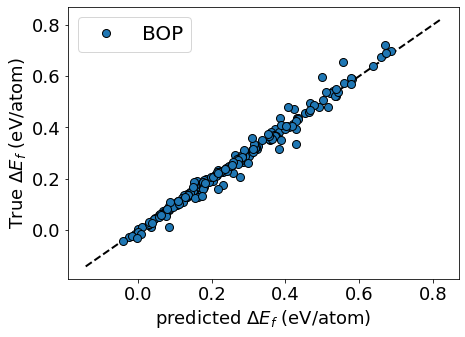

In [100]:
x_y = np.linspace(DS.target.min()-0.1, DS.target.max()+0.1, 2)
fig, ax = plt.subplots()
ax.plot(x_y, x_y, '--k', lw=2)
for name, legend in iwanttoplot.items():
    print(name, legend)
    legend = legend.replace('dataset', 'polyhedra').replace('Bond specific BOP', 'BOP')
    combi = (ModelName, name)
    if combi not in Prediction.keys():
        print(f'{combi} has not been processed yet')
        continue
    ax.plot(Prediction[combi].values, DS.target.values, 'o', markersize=8, markeredgecolor='k', color=colors[name], label=legend, )
ax.set_xlabel(r'predicted $\Delta E_f$ (eV/atom)')
ax.set_ylabel(r'True $\Delta E_f$ (eV/atom)')
ax.legend()
fig.savefig(os.path.join(DS.dataset,'graphs', f'{DS.dataset}_{ModelName}_predictionline_{target_case}.pdf'))

# Recursivity

REDO RECURSIVITY TESTS
 - redefine model
 - refit model

In [101]:
Tester = DatasetTester()

In [102]:
from importlib.machinery import SourceFileLoader
Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
# from Tools.DatasetTools.DatasetOperator import Dataset
# DS = SourceFileLoader('DS', 'Tools/DatasetTools/DatasetOperator.py').load_module().Dataset('Fe-Mo')
# Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
# samplesplit = DS.get_samplesplit()

In [103]:
import copy

In [104]:
RecursivityModels = copy.deepcopy(Models[ModelName])

# Fits on reduced features 

In [105]:
ReducedFittedModels = {}

In [106]:
Reduced_features_fitting_location = os.path.join(DS.resultslocation, f'ReducedFeaturesCVSearch_{target_case}.pkl')

In [107]:
if os.path.exists(Reduced_features_fitting_location):
    with open(Reduced_features_fitting_location, 'rb') as pkl:
        ReducedFittedModels = pickle.load(pkl)

ValueError: node array from the pickle has an incompatible dtype:
- expected: {'names': ['left_child', 'right_child', 'feature', 'threshold', 'impurity', 'n_node_samples', 'weighted_n_node_samples', 'missing_go_to_left'], 'formats': ['<i8', '<i8', '<i8', '<f8', '<f8', '<i8', '<f8', 'u1'], 'offsets': [0, 8, 16, 24, 32, 40, 48, 56], 'itemsize': 64}
- got     : [('left_child', '<i8'), ('right_child', '<i8'), ('feature', '<i8'), ('threshold', '<f8'), ('impurity', '<f8'), ('n_node_samples', '<i8'), ('weighted_n_node_samples', '<f8')]

In [ ]:
MO.modeloptions

In [ ]:
maxorders = [8, 10, 12, 14, 16]
for name, model in Models.items():
    if name != ModelName:
        continue
    progress = tqdm(product(Features.items(), maxorders), total=len(maxorders)*len(Features))
    for (key, features), maxorder in progress:  # maxorder in range(4,9):
        progress.set_description(name+', '+key+', '+str(maxorder)+':  ')
        if (name, key, maxorder) in ReducedFittedModels.keys():
            continue
        if 'no CNAV' in key:
            continue
        if 'BOP' not in key:
            continue
        if 'Projections' not in key:
            continue
        if (name, key, maxorder) in ReducedFittedModels.keys():
            continue
        if maxorder < 10:
            regexstr = f'^(?!.*_[{maxorder}-9]_.*|.*_1[0-9]_.*)'
        else:
            regexstr = f'^(?!.*_1[{maxorder - 10}-9]_.*)'
#        for key, features in progress: #Features.items():
        model = GridSearchCV(
            Models[name],
            MO.modeloptions[name], 
            scoring='neg_root_mean_squared_error', 
            cv = 5,#samplefolds,
            return_train_score= True,
        )
        if 'BOP' in key:
            reducedfeatures = features.filter(regex=regexstr)
        else:
            reducedfeatures = features
        ReducedFittedModels[(name, key, maxorder)] = model.fit(reducedfeatures, DS.target)

In [ ]:
with open(Reduced_features_fitting_location, 'wb') as pkl:
    pickle.dump(ReducedFittedModels, pkl)

In [ ]:
somecombi = (ModelName, 'Projections BOP')

In [ ]:
features_in_reduced = pd.Index(ReducedFittedModels[somecombi+(16,)].feature_names_in_)

In [ ]:
best_scores_reduced = collect_best_scores(ReducedFittedModels)

In [ ]:
model = best_scores_reduced.index.get_level_values(0)

In [ ]:
test_scores_vs_max = best_scores_reduced.unstack().transpose().loc['test'].dropna(axis=1)

In [ ]:
full_model_test_scores = best_scores_reduced.unstack().transpose().loc['test']

In [ ]:
fig, ax = plt.subplots(figsize=(15, 8))
for combi in test_scores_vs_max.columns:
#    if 'BOP' not in combi[1]:
#        continue
#    if 'Canonical' in combi[1]:
#        continue
#    if 'dataset' not in combi[1]:
#        continue
    drmse = (test_scores_vs_max[combi].values - test_scores_vs_max[combi].values[-1])*1000  # - full_model_test_scores[combi[0]][combi[1]]*1000
    l = ax.plot(test_scores_vs_max[combi].index, drmse, label=combi[1])[0]
#    ax.axhline(full_model_test_scores[combi[0]][combi[1]]*1000,ls='--', color=l.get_color())
ax.legend(bbox_to_anchor = (1, 1))
ax.set_ylabel(r'$\Delta$ test RMSE($\Delta E_f$) (meV/atom)')
ax.set_xlabel(r'max order in recursion features: $a_{1,..,n/2}, b_{1,..,n/2}, \mu_{1,..,n}, \sigma_{1,...,n}$')
fig.tight_layout()
fig.savefig(os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_full_recursivity_{target_case}.eps'))

# Feature Importances 

In [ ]:
def get_importances(voting_regressor):
    importances = {}
    for combi, estimator in voting_regressor.items():
        print(combi[1])
        X = DS.Features[combi[1]]#[selected]
        allimportances = get_importances(estimator , X,  DS.target)
        importances[combi] =allimportances #  [allimportances['importances_mean']>=allimportances['importances_mean']['random']]
    for (modelname, name),timportances in importances.items():
        timportances.sort_values(by='importances_mean', inplace=True, ascending=False)
    return importances


In [ ]:
def plot_importances(importances):
    for name, timp in importances.items():
        fig, ax = plt.subplots(figsize=(12, 8))
        x = timp['importances_mean'][:20]
        sns.barplot(y=timp.index[:20], x=x , ax=ax, color='Purple')
        ylabels = [get_str_formatted(fname) for fname in x.index]
        ax.set_xscale('log')
        ax.set_xlabel('permutation importance')
        ax.set_yticklabels(ylabels, fontsize=12)
        fig.suptitle(name[1].replace('dataset', 'polyhedra'))
        fig.tight_layout()

# Errors by phase by model

In [ ]:
train_errors = {}
rmse = {}

In [ ]:
absolute_errors = {}

In [ ]:
iwanttoseeerrors = ['0.7 Projections OS BOP', 'SOAP_specific', 'ACE']

In [ ]:
for combi, thisprediction in Prediction.items(): # voting_regressor.items():
    if 'sOS' in combi[1]:
        continue
    if combi[1] not in iwanttoseeerrors:
        continue
    print(combi)
    absolute_errors[combi] = thisprediction.sub(DS.target, axis=0)
    rmse[combi] = {}
    for phase in DS.BS.Phase.unique():
        thiserrors = absolute_errors[combi][DS.BS.Phase == phase]**2
        rmse[combi][phase] =  np.sqrt(thiserrors.sum()/len(thiserrors)).values[0]
    rmse[combi]['total'] = np.sqrt((thisprediction.sub(DS.target, axis=0)**2/len(thisprediction)).sum(axis=0)).values[0]
    rmse[combi]['test'] = np.sqrt(
        (
            (thisprediction.loc[DS.samplesplit['test']].sub(DS.target[DS.samplesplit['test']], axis=0)**2).sum()/len(DS.samplesplit['test'])
        ).values[0]
    )

In [ ]:
rmse

In [ ]:
width = plt.rcParams['figure.figsize'][0]*len(iwanttoseeerrors)*(3/5)
height = plt.rcParams['figure.figsize'][1]
fig, axes = plt.subplots(1, len(rmse),sharey=True, figsize=(width, height))
for (combi, thiserrors), ax in zip(absolute_errors.items(), axes):
    sns.violinplot(
        y=absolute_errors[combi][target_case].map(np.log10), 
        x=DS.StructureNames, hue=DS.Features['dataset']['Mag'], split=True, ax=ax
    )
    ax.axhline(np.log10(rmse[combi]['total']),color='k', label='rmse')
    ax.get_legend().remove()
    ax.set_xlabel('')
    ax.set_ylabel(combi[1].replace('_specific', ''))
fig.tight_layout()

In [ ]:
rmsedf = pd.DataFrame.from_dict(rmse, orient = 'index')

In [ ]:
rmsedf.sort_values(by=(ModelName, '0.7 Projections OS BOP'), axis = 1, inplace=True)

In [ ]:
rmsedf.sort_values(by='total', inplace=True)

In [ ]:
important = [(ModelName, '0.7 Projections OS BOP'), (ModelName, 'ACE'), (ModelName, 'SOAP_specific')]

In [ ]:
from matplotlib.colors import LogNorm, Normalize
ax = sns.heatmap(rmsedf.loc[important]*1000,  cbar_kws={'label': 'RMSE (meV /  at)'}, norm=LogNorm())